In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 



In [2]:
df=pd.read_csv("/Users/bhijanbastola/Desktop/Flood/Data/CORRECTED_2023_2026_NEPAL_FLOOD_WEATHER_KAGGLE.csv")

In [3]:
df.head()

,date,location,river,basin,dhm_station,latitude,longitude,elevation_m,precipitation_mm,soil_moisture_0_100cm_m3m3,rain_mm,temperature_mean_c,dew_point_mean_c,precipitation_hours,relative_humidity_mean_pct,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,river_discharge_m3s
0,2023-01-01 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.315,0.0,12.2,-2.6,0,37,13.9,68.0,187,0.22
1,2023-01-02 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.315,0.0,11.1,-4.8,0,34,13.4,69.8,191,0.21
2,2023-01-03 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.314,0.0,11.5,-10.3,0,22,14.5,72.0,183,0.21
3,2023-01-04 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.314,0.0,9.6,-8.9,0,29,11.2,67.7,187,0.20
4,2023-01-05 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.314,0.0,10.1,-10.2,0,26,7.4,69.8,54,0.20


In [4]:
df.columns

Index(['date', 'location', 'river', 'basin', 'dhm_station', 'latitude',
       'longitude', 'elevation_m', 'precipitation_mm',
       'soil_moisture_0_100cm_m3m3', 'rain_mm', 'temperature_mean_c',
       'dew_point_mean_c', 'precipitation_hours', 'relative_humidity_mean_pct',
       'wind_speed_max_kmh', 'wind_gusts_max_kmh',
       'wind_direction_dominant_deg', 'river_discharge_m3s'],
      dtype='str')

In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["dhm_station", "date"]).reset_index(drop=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info(
    
)

<class 'pandas.DataFrame'>
RangeIndex: 13390 entries, 0 to 13389
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         13390 non-null  datetime64[us]
 1   location                     13390 non-null  str           
 2   river                        13390 non-null  str           
 3   basin                        13390 non-null  str           
 4   dhm_station                  13390 non-null  float64       
 5   latitude                     13390 non-null  float64       
 6   longitude                    13390 non-null  float64       
 7   elevation_m                  13390 non-null  int64         
 8   precipitation_mm             13390 non-null  float64       
 9   soil_moisture_0_100cm_m3m3   13390 non-null  float64       
 10  rain_mm                      13390 non-null  float64       
 11  temperature_mean_c           13390 non-null  float64

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,13390,2024-10-31 00:00:00,2023-01-01 00:00:00,2023-12-01 00:00:00,2024-10-31 00:00:00,2025-10-01 00:00:00,2026-08-31 00:00:00,NaN
dhm_station,13390.0,441.277,120.0,291.0,448.11,595.5,695.0,168.756008
latitude,13390.0,27.969215,26.855192,27.632222,27.897137,28.271297,29.67442,0.780239
longitude,13390.0,83.971008,80.56268,81.36565,84.861667,85.899324,87.152283,2.282525
elevation_m,13390.0,916.5,153.0,188.0,644.0,1749.0,2215.0,759.025346
precipitation_mm,13390.0,4.480344,0.0,0.0,0.1,4.2,343.7,10.930667
soil_moisture_0_100cm_m3m3,13390.0,0.308025,0.02,0.245,0.312,0.378,0.514,0.087035
rain_mm,13390.0,4.433518,0.0,0.0,0.1,4.0,343.7,10.919578
temperature_mean_c,13390.0,22.083891,5.4,17.1,23.1,27.1,36.4,5.928396
dew_point_mean_c,13390.0,15.632524,-16.2,10.3,15.8,22.4,27.6,7.621872


In [9]:
print(df.describe(include=["object"]).T)

          count unique                  top  freq
location  13390     10  Chameliya/Nayalbadi  1339
river     13390      9          Bhote Koshi  2678
basin     13390      9                Koshi  2678


/var/folders/0j/c86nz3417lg1_k7f7zrhm97h0000gn/T/ipykernel_12343/1549811156.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=["object"]).T)


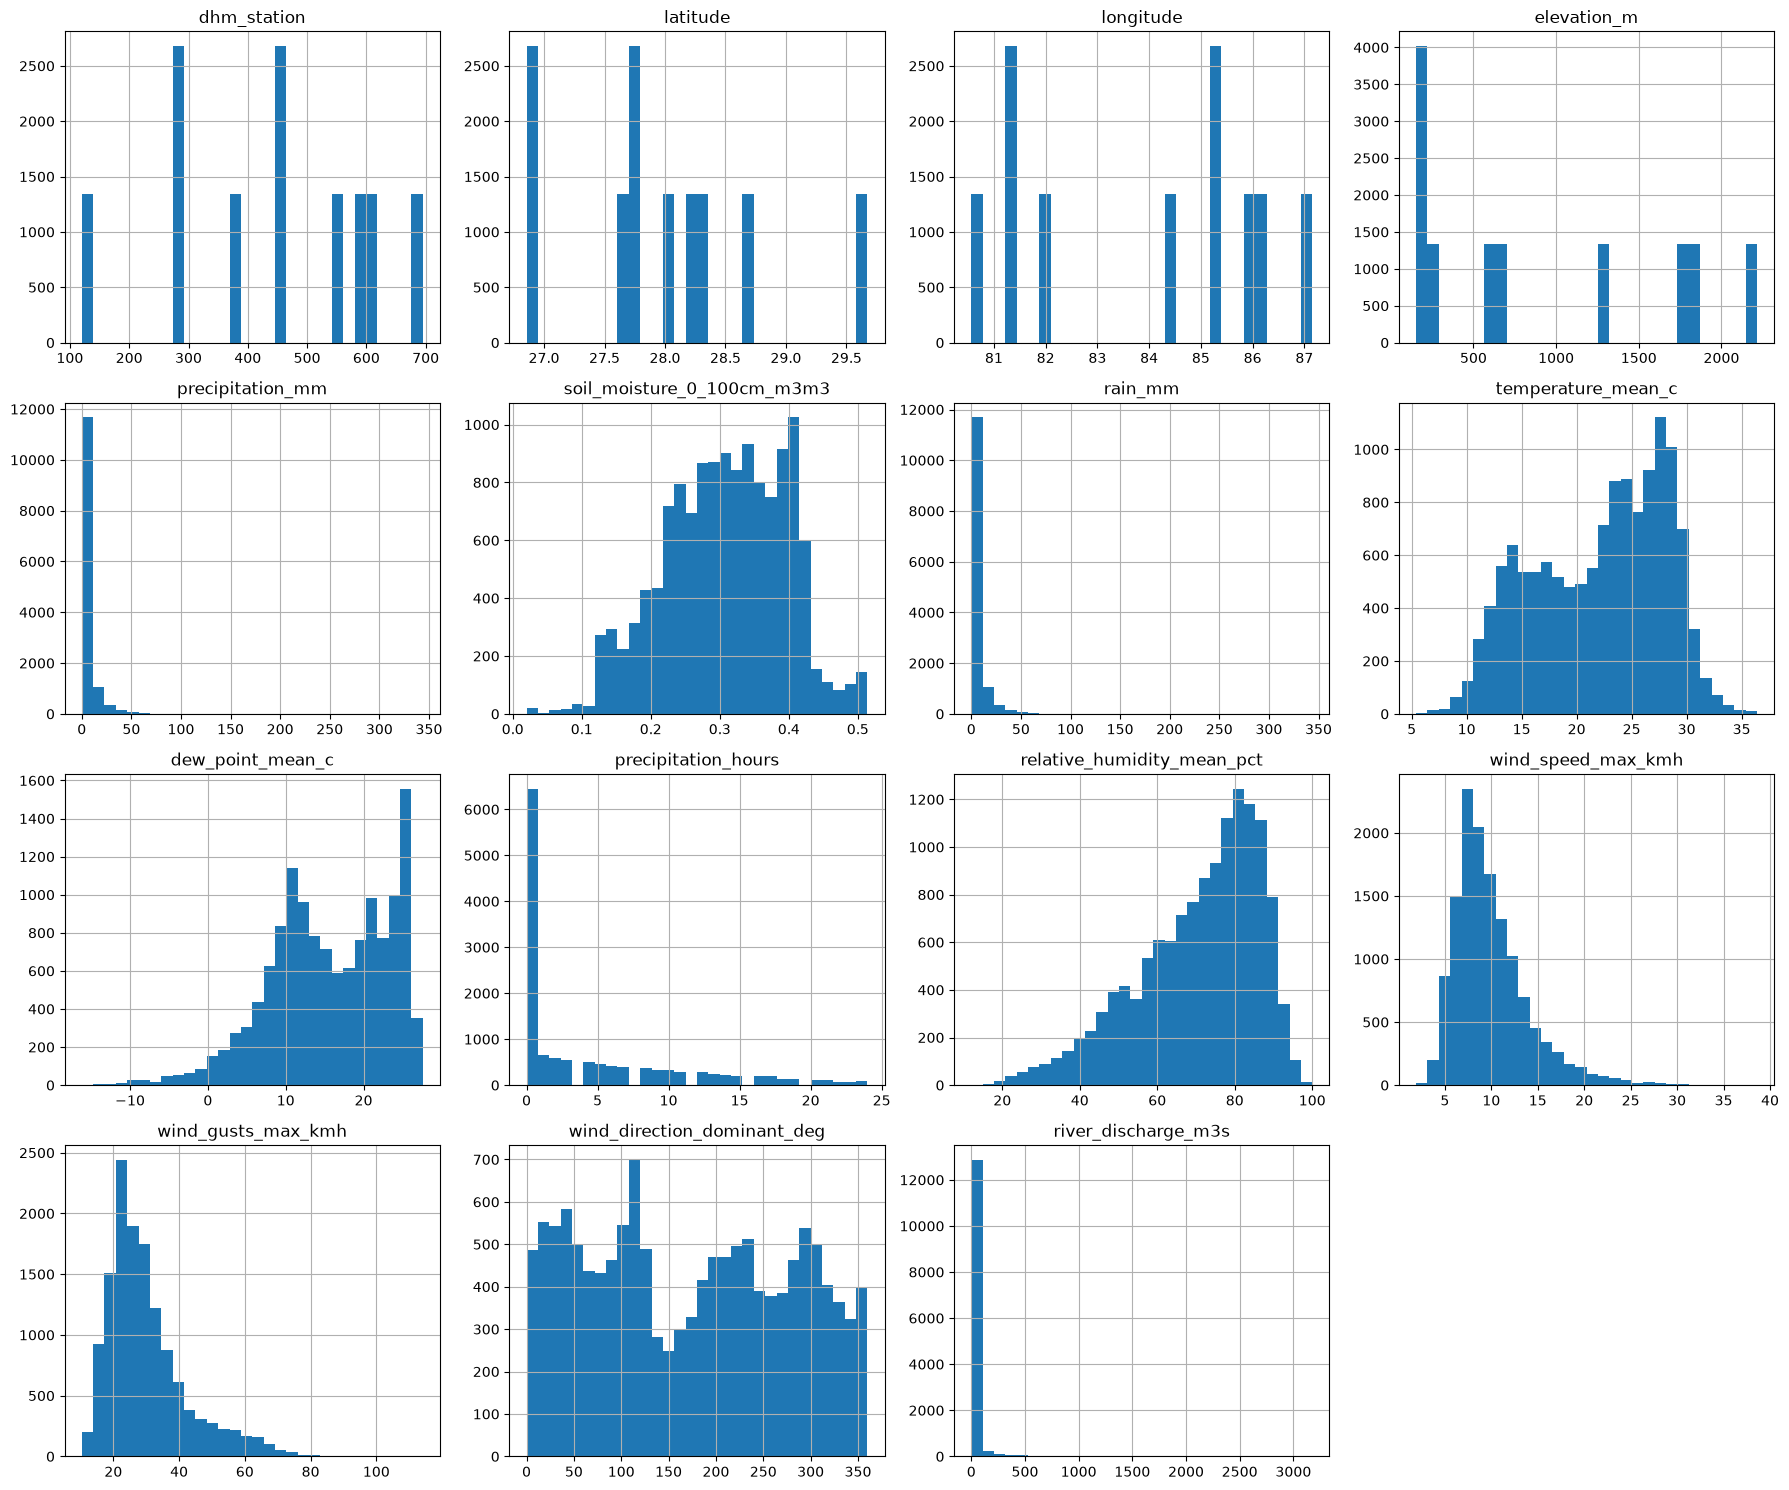

In [10]:

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numerical_cols].hist(
    figsize=(18, 15),
    bins=30
)

plt.tight_layout()
plt.show()

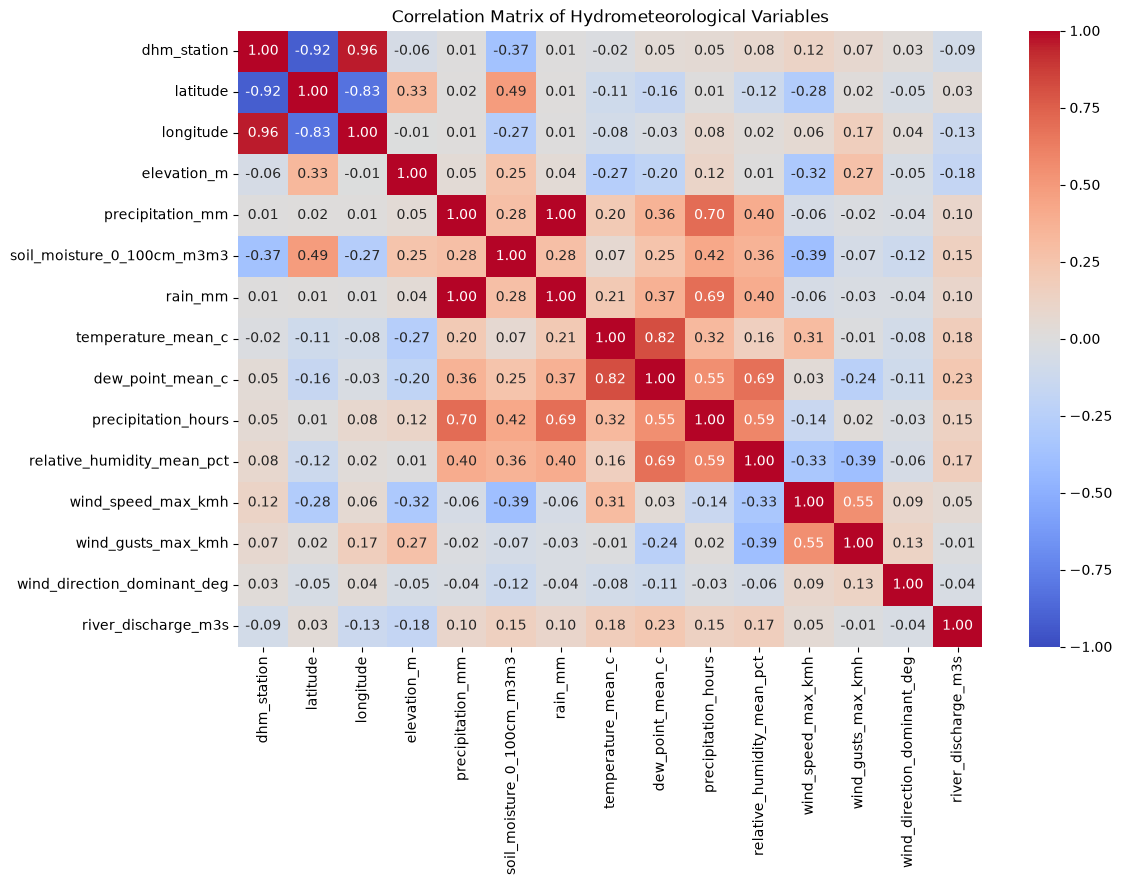

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Hydrometeorological Variables")
plt.show()

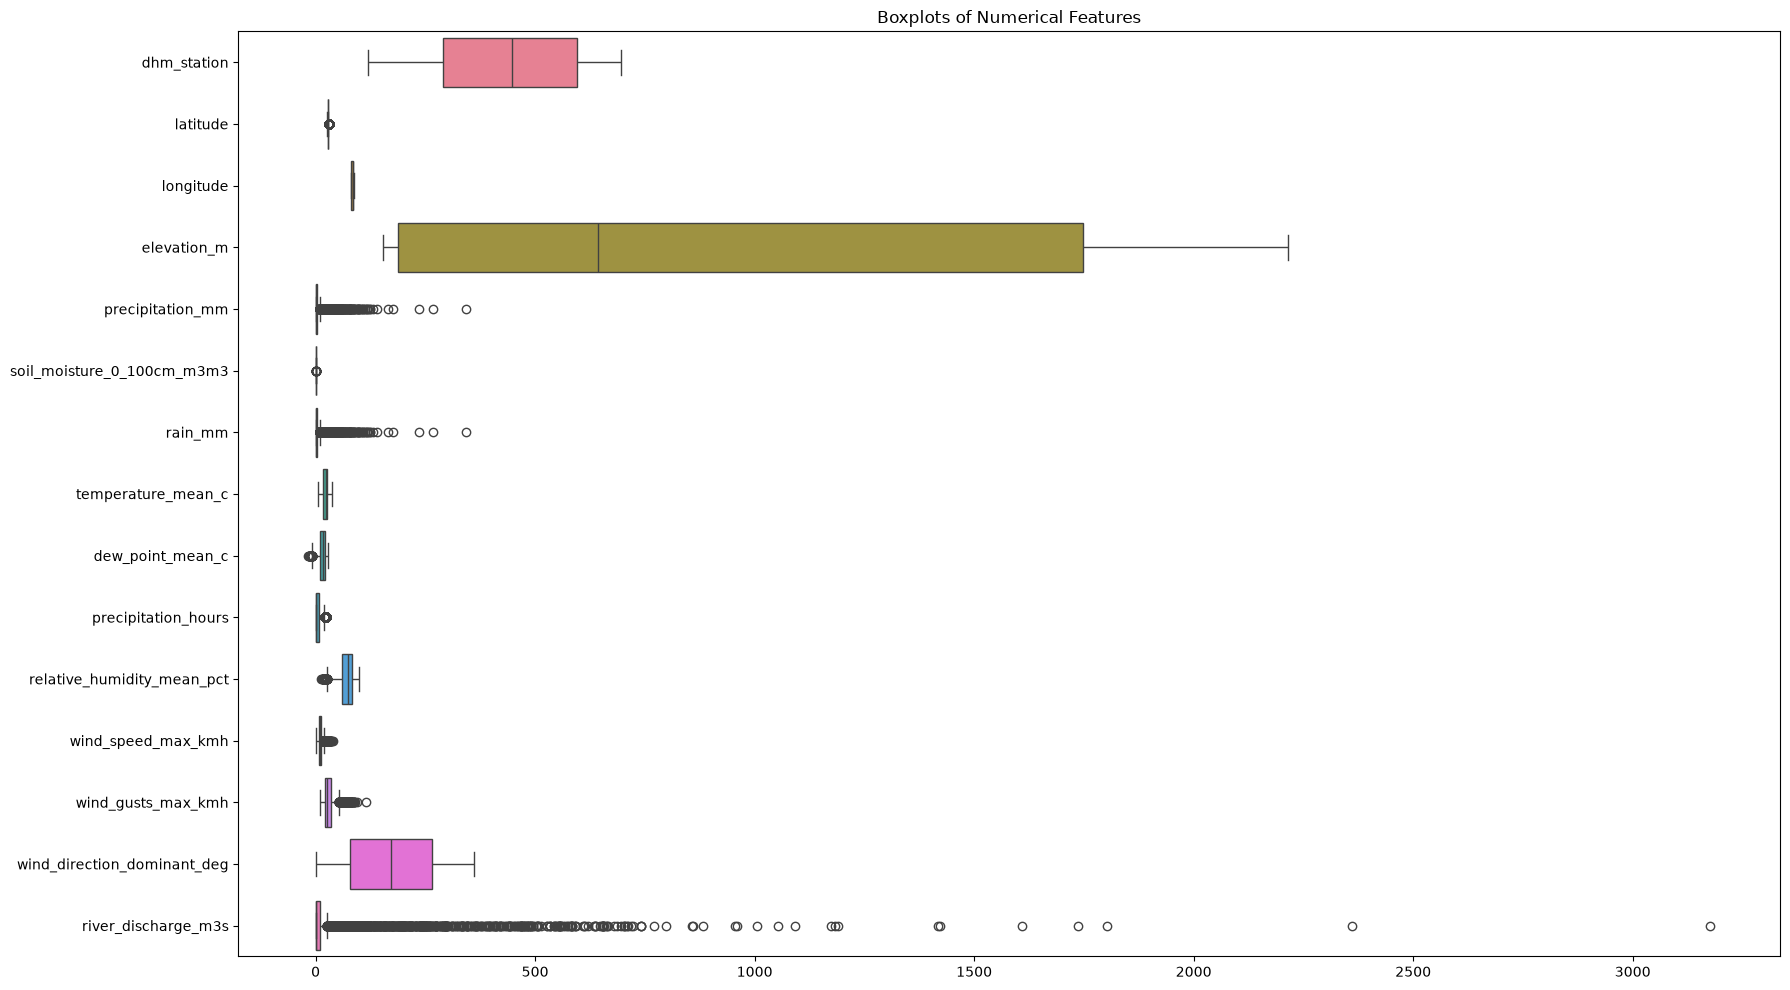

In [12]:

plt.figure(figsize=(18, 10))

sns.boxplot(
    data=df[numerical_cols],
    orient="h"
)

plt.title("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

The provided image, titled "Boxplots of Numerical Features," displays horizontal boxplots that illustrate the statistical distribution, range, and presence of extreme values across 15 numerical variables in the dataset. Broad geographical features like `elevation_m`, `dhm_station`, and `wind_direction_dominant_deg` exhibit wide box spans representing large Interquartile Ranges (IQRs) without distinct isolated points. In contrast, hydrometeorological variables—most notably `precipitation_mm`, `rain_mm`, and `river_discharge_m3s`—show heavily right-skewed distributions characterized by compact box bodies near zero and long trails of extreme individual data points extending far to the right, with peak discharge values exceeding $3{,}000\text{ m}^3/\text{s}$.


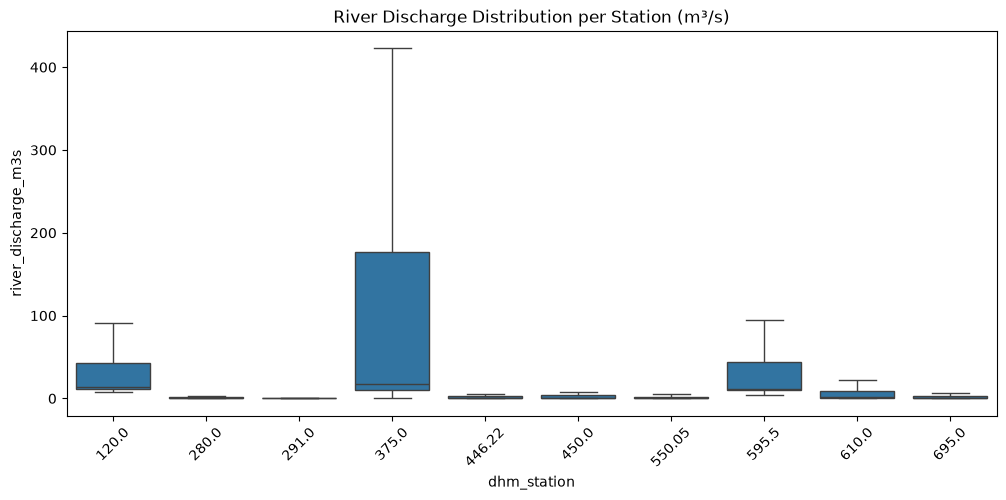

In [13]:
# C. Discharge Distribution per Station
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df, x="dhm_station", y="river_discharge_m3s", showfliers=False
)
plt.xticks(rotation=45)
plt.title("River Discharge Distribution per Station (m³/s)")
plt.show()

The image titled "River Discharge Distribution per Station ($\text{m}^3/\text{s}$)" displays vertical boxplots comparing river discharge values across ten distinct monitoring stations (`dhm_station` IDs ranging from `120.0` to `695.0`). The plot illustrates substantial spatial variation in streamflow magnitudes across locations: while most stations (e.g., `280.0`, `291.0`, `446.22`, `450.0`, `550.05`, and `695.0`) maintain consistently low discharge rates near zero with narrow Interquartile Ranges (IQRs), station `375.0` exhibits by far the largest baseline volume and variability, with its upper whisker reaching over $400\text{ m}^3/\text{s}$. Stations `120.0` and `595.5` display moderate discharge levels, peaking around $100\text{ m}^3/\text{s}$.

This pronounced station-to-station variance confirms that high-flow conditions cannot be defined using a single global threshold across the whole dataset. Instead, station-specific thresholds (such as each station's individual 95th percentile) are essential to account for localized river capacities and avoid biasing model predictions toward larger catchments like station `375.0`.

In [14]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)

skewness


river_discharge_m3s            12.402578
rain_mm                         7.906414
precipitation_mm                7.874376
wind_speed_max_kmh              1.479460
wind_gusts_max_kmh              1.378487
precipitation_hours             1.361017
latitude                        0.567130
elevation_m                     0.471186
wind_direction_dominant_deg     0.072560
soil_moisture_0_100cm_m3m3     -0.221692
longitude                      -0.225921
dhm_station                    -0.311124
temperature_mean_c             -0.324911
dew_point_mean_c               -0.511448
relative_humidity_mean_pct     -0.770785
dtype: float64

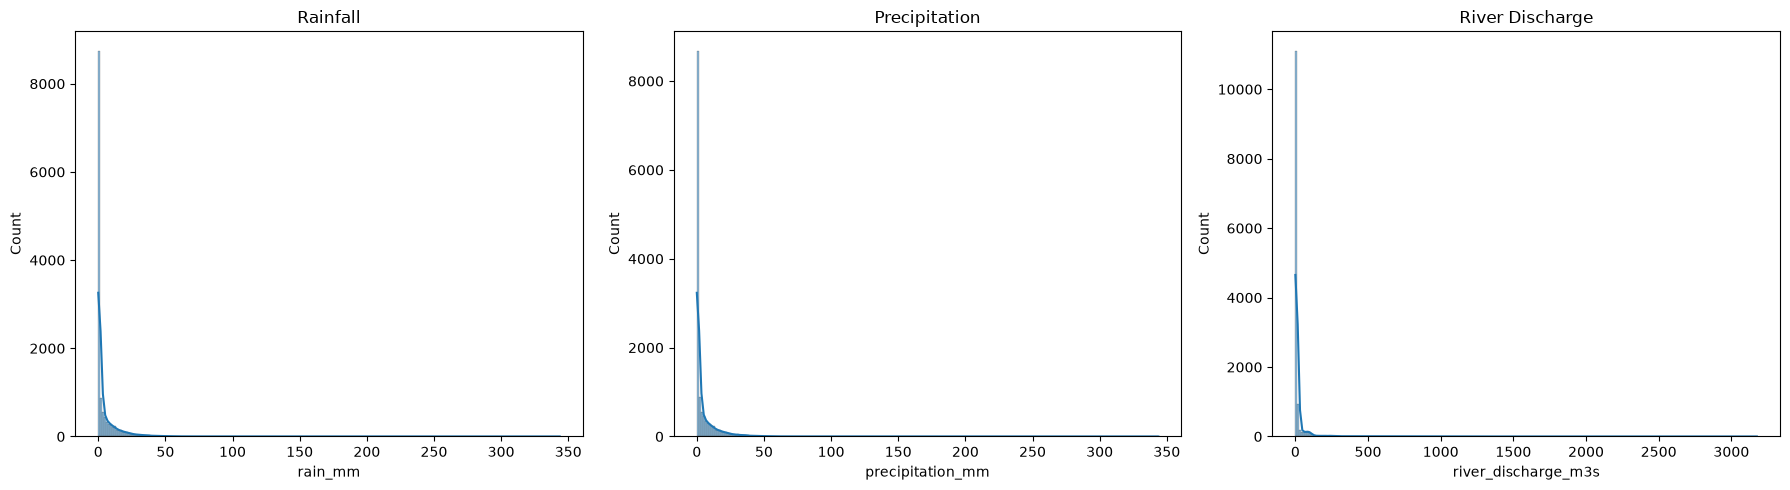

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["rain_mm"], kde=True, ax=axes[0])
axes[0].set_title("Rainfall")

sns.histplot(df["precipitation_mm"], kde=True, ax=axes[1])
axes[1].set_title("Precipitation")

sns.histplot(df["river_discharge_m3s"], kde=True, ax=axes[2])
axes[2].set_title("River Discharge")

plt.tight_layout()
plt.show()

The image displays three side-by-side distribution plots (histograms overlaid with Kernel Density Estimation curves) for "Rainfall" (`rain_mm`), "Precipitation" (`precipitation_mm`), and "River Discharge" (`river_discharge_m3s`), illustrating extreme right-skewness across all three hydrometeorological variables. Each plot is dominated by a massive peak near zero—with counts exceeding 8,000 to 11,000 observations—reflecting that baseline environmental conditions consist primarily of dry or low-flow days. The distributions exhibit long, sparse right tails stretching up to 350 mm for rainfall/precipitation and over 3,000 m³/s for river discharge, highlighting the rarity and severity of high-magnitude precipitation and flood events within the dataset.

In [16]:
df[[
    "rain_mm",
    "precipitation_mm"
]].corr()

,rain_mm,precipitation_mm
rain_mm,1.000000,0.998538
precipitation_mm,0.998538,1.000000


In [17]:
# 2. Split by time: train on 2023-2025, test on 2026
split_date = "2026-01-01"
train_part = df[df["date"] < split_date]


In [18]:
# 3. Create the TARGET
threshold = train_part.groupby("dhm_station")["river_discharge_m3s"].quantile(0.95)
df["threshold"] = df["dhm_station"].map(threshold)
df["discharge_tomorrow"] = df.groupby("dhm_station")["river_discharge_m3s"].shift(-1)
df["target"] = (df["discharge_tomorrow"] > df["threshold"]).astype(int)

In [19]:
# 3. Station info table (the Streamlit app uses this)
station_info = df.groupby("dhm_station").agg(location=("location", "first"),
                                             elevation_m=("elevation_m", "first"))
station_info["threshold"] = threshold

In [20]:
#Feature Engineering 
# discharge compared to the station's own "high" level (fixes skew)
df["discharge_ratio"] = df["river_discharge_m3s"] / df["threshold"]
df["discharge_yesterday"] = df.groupby("dhm_station")["discharge_ratio"].shift(1)
df["discharge_change"] = df["discharge_ratio"] - df["discharge_yesterday"]
 
# rain (log fixes skew) and rain over past days
df["rain_log"] = np.log1p(df["precipitation_mm"])
df["rain_3d"] = df.groupby("dhm_station")["precipitation_mm"].rolling(3).sum().reset_index(level=0, drop=True)
df["rain_7d"] = df.groupby("dhm_station")["precipitation_mm"].rolling(7).sum().reset_index(level=0, drop=True)
 
# soil moisture over past 3 days
df["soil_3d"] = df.groupby("dhm_station")["soil_moisture_0_100cm_m3m3"].rolling(3).mean().reset_index(level=0, drop=True)
 
# wet soil + rain
df["soil_x_rain"] = df["soil_moisture_0_100cm_m3m3"] * df["rain_3d"]
 
# season
df["month"] = df["date"].dt.month
 
features = ["discharge_ratio", "discharge_yesterday", "discharge_change",
            "rain_log", "rain_3d", "rain_7d",
            "soil_moisture_0_100cm_m3m3", "soil_3d", "soil_x_rain",
            "temperature_mean_c", "relative_humidity_mean_pct",
            "elevation_m", "month"]
 
# 5. Remove rows with missing values (created by shift and rolling)
df = df.dropna(subset=features + ["discharge_tomorrow"])
 
# 6. Split by date
train = df[df["date"] < split_date]
test = df[df["date"] >= split_date]

In [21]:
df = df.drop(columns=["rain_mm", "dew_point_mean_c", "wind_direction_dominant_deg",
                      "latitude", "longitude", "location", "river", "basin"])

In [22]:

X_train, y_train = train[features], train["target"]
X_test, y_test = test[features], test["target"]

In [24]:

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

# Calculate class imbalance for XGBoost
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive


# Define models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        verbose=1
    ),

    "Gradient Boosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        class_weight="balanced",
        random_state=42,
        verbose=1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        verbose=1
    )
}

In [25]:
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score,accuracy_score

In [26]:
# If today's discharge ratio > 1,
# predict tomorrow will be a high-flow day
baseline_pred = (test["discharge_ratio"] > 1).astype(int)

baseline_results = {
    "PR-AUC": average_precision_score(
        y_test,
        test["discharge_ratio"]
    ),

    "Precision": precision_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    
    "Accuracy": accuracy_score(
        y_test,
        baseline_pred,
        
        )
}

print("Persistence Baseline")
for metric, value in baseline_results.items():
    print(f"{metric}: {value:.4f}")

Persistence Baseline
PR-AUC: 0.4395
Precision: 0.5091
Recall: 0.5000
F1: 0.5045
Accuracy: 0.9773


In [27]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "PR-AUC": average_precision_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Accuracy":accuracy_score(y_test,y_pred)
    }

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s


Binning 0.001 GB of training data: 

[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


0.586 s
Binning 0.000 GB of validation data: 0.001 s
Fitting gradient boosted rounds:
Fit 80 trees in 1.114 s, (2480 total leaves)
Time spent computing histograms: 0.169s
Time spent finding best splits:  0.100s
Time spent applying splits:      0.139s
Time spent predicting:           0.004s


/Users/bhijanbastola/Desktop/Flood/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:29:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
results_df = pd.DataFrame(results).T.round(3).sort_values("PR-AUC", ascending=False)
print(results_df, "\n")

                   PR-AUC  Precision  Recall     F1  Accuracy
Random Forest       0.522      0.467   0.625  0.534     0.975
XGBoost             0.518      0.377   0.821  0.517     0.964
Gradient Boosting   0.507      0.362   0.750  0.488     0.964 



In [29]:
# Remove baseline
model_results = results_df.drop(
    index="Persistence Baseline",
    errors="ignore"
)

# Find best model based on PR-AUC
best_model_name = model_results["PR-AUC"].idxmax()

print("Best model:", best_model_name)

Best model: Random Forest


In [30]:
best_model = models[best_model_name]

In [31]:
# import joblib

# bundle = {
#     "model": best_model,
#     "model_name": best_model_name,
#     "features": features,
#     "station_info": station_info,
#     "results": results_df
# }

# joblib.dump(bundle, "flood_model.joblib")

# results_df.to_csv(
#     "model_comparison.csv",
#     index=True
# )

# print("Saved:")
# print("- flood_model.joblib")
# print("- model_comparison.csv")